In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import NullLocator
from scipy.stats import mannwhitneyu
from tqdm import trange

DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../flatten/processed-data/"
DATA_PATH3 = "../../18-Y2H-data/processed-data/"
ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [3]:
# load the datasets with node centrality information and get nodes in both
ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251209-s288c-annotated-PPI-net.pkl")
y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")

In [4]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = ms_nodes['betweenness_centrality'].quantile(1 - cut)
ms_hubs     = ms_nodes[ms_nodes['betweenness_centrality'] >= ms_threshold]
ms_nothub   = ms_nodes[ms_nodes['betweenness_centrality'] <  ms_threshold]

y2h_threshold = ms_nodes['Y2H_betweenness_centrality'].quantile(1 - cut)
y2h_hubs      = ms_nodes[ms_nodes['Y2H_betweenness_centrality'] >= y2h_threshold]
y2h_nothub    = ms_nodes[ms_nodes['Y2H_betweenness_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.00178; there are 393 hubs and 3534 non hubs
Threshold for defining a hub in Y2H data is 0.00388; there are 147 hubs and 1318 non hubs


## Supplement 1
* Create boxplots of protein half-life (min) for bottlenecks and non-bottlenecks in mass spec and Y2H datasets (hubs and non-hubs based on betweenness centrality)

In [6]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid huge memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_for_log(s):
    return (
        s.replace([np.inf, -np.inf], np.nan)
         .dropna()
         .loc[lambda x: x > 0]
    )
    
ms_nothub_vals  = clean_for_log(ms_nothub["Villen_halflife_min"])
ms_hub_vals     = clean_for_log(ms_hubs["Villen_halflife_min"])
y2h_nothub_vals = clean_for_log(y2h_nothub["Villen_halflife_min"])
y2h_hub_vals    = clean_for_log(y2h_hubs["Villen_halflife_min"])

groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|██████████████████████████████████████████████████| 1000000/1000000 [00:15<00:00, 64683.69it/s]


MS hubs: median=126.90, 95% CI=(119.40, 135.60), n=328)


Bootstrapping medians: 100%|██████████████████████████████████████████████████| 1000000/1000000 [00:35<00:00, 28064.70it/s]


MS non-hubs: median=130.20, 95% CI=(127.20, 132.60), n=2382)


Bootstrapping medians: 100%|██████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 77596.06it/s]


Y2H hubs: median=141.60, 95% CI=(134.40, 151.20), n=101)


Bootstrapping medians: 100%|██████████████████████████████████████████████████| 1000000/1000000 [00:21<00:00, 46089.79it/s]

Y2H non-hubs: median=132.90, 95% CI=(129.60, 136.80), n=946)


In [7]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS bottlenecks vs MS non-bottlenecks")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

print("\nY2H bottlenecks vs Y2H bottlenecks")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on Villen_halflife_min ===

MS bottlenecks vs MS non-bottlenecks
n(hubs) = 328, n(non-hubs) = 2382
median(hubs) = 126.90, median(non-hubs) = 130.20
U = 369639.50, p = 0.1138

Y2H bottlenecks vs Y2H bottlenecks
n(hubs) = 101, n(non-hubs) = 946
median(hubs) = 141.60, median(non-hubs) = 132.90
U = 54499.00, p = 0.0199


/tmp/ipykernel_852400/2506483779.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


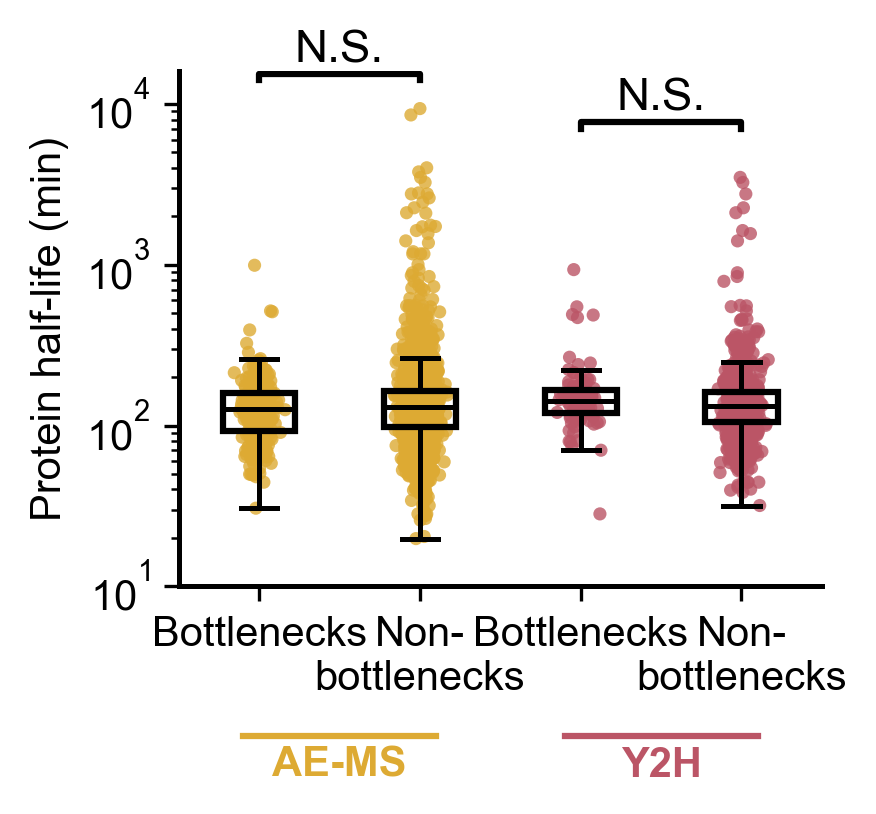

In [10]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals, y2h_hub_vals, y2h_nothub_vals]
group_colors = [MS_COLOR,    MS_COLOR,       Y2H_COLOR,    Y2H_COLOR]

# --- Scatter first (lower zorder) ---
for i, (vals, color) in enumerate(zip(group_vals, group_colors), start=1):
    x_jitter = i + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Bottlenecks", "Non-\nbottlenecks", "Bottlenecks", "Non-\nbottlenecks"],
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_yscale("log")
ax.set_ylim(12, 16000)

ax.set_ylabel("Protein half-life (min)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ms_pair_max  = max(ms_hub_vals.max(), ms_nothub_vals.max())
y2h_pair_max = max(y2h_hub_vals.max(), y2h_nothub_vals.max())

#ms_y  = ms_pair_max * 2.0
ms_y  = 14000
y2h_y = y2h_pair_max * 2.0

add_bracket_with_text(ax, 1, 2, ms_y,  "N.S.")
add_bracket_with_text(ax, 3, 4, y2h_y, "N.S.")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# AE-MS under boxes 1–2
ax.plot(
    [0.9, 2.1], [-0.29, -0.29],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)
ax.text(
    1.5, -0.31, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

# Y2H under boxes 3–4
ax.plot(
    [2.9, 4.1], [-0.29, -0.29],
    transform=trans,
    clip_on=False,
    color=Y2H_COLOR,
    lw=1.5,
)
ax.text(
    3.5, -0.31, "Y2H",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=Y2H_COLOR,
)
ax.tick_params(axis="x", labelsize=8)
for label in ax.get_xticklabels():
    label.set_rotation(0)   # or 45
    label.set_ha("center")
    label.set_fontsize(10)
plt.yticks([10, 100, 1000, 10000])
plt.tight_layout()
plt.savefig(f"{OUT_PATH}Supp-1.svg")
plt.show()